### Build A Basic Chatbot With Langgraph(GRAPH API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [2]:

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

# graph_builder = StateGraph(State)
# graph_builder

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002B156129FD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002B15612AA50>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
llm=init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002B1561B2710>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002B1561B3110>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
## Node Functionality
def chatbot(state:State):
    return {"messages": [llm.invoke(state["messages"])]}

In [8]:
graph_builder = StateGraph(State)

# Adding node
graph_builder.add_node("llmchatbot", chatbot)
# Adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# compile the graph
graph = graph_builder.compile()

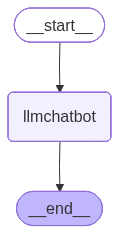

In [9]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response=graph.invoke({"messages":"Hi"})

In [11]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [12]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm always happy to chat and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?


### Chatbot with Tool

In [14]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [20]:
## Custom function

def multiply(a:int,b:int)->int:
    """Multiply a and b

    Agrs:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [26]:
tools=[tool,multiply]

In [27]:
llm_with_tool=llm.bind_tools(tools)

In [28]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002B1561B2710>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002B1561B3110>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search 

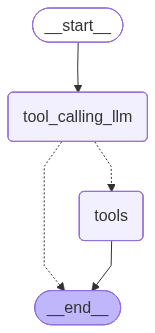

In [30]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [23]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/ai-tech-jobs-skills-employers-want-2026-7", "title": "Companies are hiring for something AI can\'t do, a review of millions of job listings found - Business Insider", "score": 0.58123237, "published_date": "Fri, 03 Jul 2026 20:27:34 GMT", "content": "# Companies are hiring for something AI can\'t do, a review of millions of job listings found. If you work in tech, AI might not be replacing your job, though it\'s changing what employers want from you. A recent analysis by the labor and market data platform Draup found that while AI is changing technical roles, it isn\'t reducing demand for tech workers. Draup said AI is expanding the job market, not shrinking it. \\"AI isn\'t reducing the need for technical talent, but it is changing what makes technical talent valuable,\\" Draup CEO Vijay Swaminathan said in a post on the company\'s website. AI an

In [31]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (eg81eh2hb)
 Call ID: eg81eh2hb
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

null


In [33]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (cgpyaer36)
 Call ID: cgpyaer36
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [34]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (wy2f0y0bz)
 Call ID: wy2f0y0bz
  Args:
    query: recent ai news
    search_depth: basic
    topic: news
  multiply (f8yscwqz6)
 Call ID: f8yscwqz6
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newser.com/story/391854/china-makes-a-big-advance-in-global-ai-race.html", "title": "China May Have Just 'Reset' the AI Race - Newser", "score": 0.6628188, "published_date": "Mon, 29 Jun 2026 18:55:00 GMT", "content": "Image 1: Newser - Current News - Breaking StoriesImage 2: Newser - Current News - Breaking Stories. Image 8: Newser - Current News - Breaki

### ReAct Agent Architecture

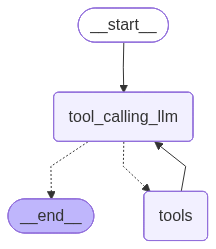

In [36]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [37]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (k076vgwqn)
 Call ID: k076vgwqn
  Args:
    query: recent ai news
    search_depth: basic
    topic: news
  multiply (6g9fstjhn)
 Call ID: 6g9fstjhn
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newser.com/story/391854/china-makes-a-big-advance-in-global-ai-race.html", "title": "China May Have Just 'Reset' the AI Race - Newser", "score": 0.6628188, "published_date": "Mon, 29 Jun 2026 18:55:00 GMT", "content": "Image 1: Newser - Current News - Breaking StoriesImage 2: Newser - Current News - Breaking Stories. Image 8: Newser - Current News - Breaki

### Adding Memory In Agentic Graph

In [39]:
response=graph.invoke({"messages":"Hello my name is Gopi"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Gopi
================================== Ai Message ==================================

Hello Gopi, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [40]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and I don't have any prior knowledge about you. If you'd like to share your name, I'd be happy to chat with you!


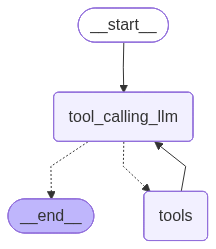

In [44]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [45]:
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"Hi my name is Gopi"}, config=config)
response

{'messages': [HumanMessage(content='Hi my name is Gopi', additional_kwargs={}, response_metadata={}, id='c2d5d19e-51e3-4849-8be8-a54bd8bc0451'),
  AIMessage(content="Hello Gopi, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1778, 'total_tokens': 1805, 'completion_time': 0.07263744, 'completion_tokens_details': None, 'prompt_time': 0.189062041, 'prompt_tokens_details': None, 'queue_time': 0.051514355, 'total_time': 0.261699481}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2c5f-10ba-7772-af4a-cfb01ac55072-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1778, 'output_tokens': 27, 'total_tokens': 1805})]}

In [47]:
response["messages"][-1].content

"Hello Gopi, it's nice to meet you. Is there something I can help you with or would you like to chat?"

In [48]:
response=graph.invoke({"messages":"Hey What is my name?"}, config=config)
print(response["messages"][-1].content)

Your name is Gopi.


In [49]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Yes, I remember your name, it's Gopi.


### Streaming

In [51]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [53]:
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

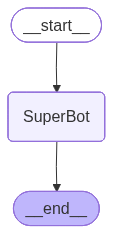

In [54]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [55]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='72a2f41d-96e2-4198-a6c3-dd7498bba498'),
  AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, and I'm sure you must be excited about the recent matches and tournaments. Who's your favorite cricket team or player? Are you more into Test cricket, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 45, 'total_tokens': 98, 'completion_time': 0.183293772, 'completion_tokens_details': None, 'prompt_time': 0.001267509, 'prompt_tokens_details': None, 'queue_time': 0.050982521, 'total_time': 0.184561281}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2c66-a393-7d30-a356-77a50df0f7e9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'

## Streaming
### Methods: .stream() and astream()

### -These methods are sync and async methods for streaming back results.
### Additional parameters in streaming modes for graph state

### -values : This streams the full state of the graph after each node is called.
### -updates : This streams updates to the state of the graph after each node is called.

In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

#stream_mode="updates" will give only"AIMessage" 
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Krish. Cricket is an exciting sport, and it's great that you enjoy it. Are you a fan of a particular team or player? Do you play cricket yourself, or do you just enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 45, 'total_tokens': 93, 'completion_time': 0.141548682, 'completion_tokens_details': None, 'prompt_time': 0.001959353, 'prompt_tokens_details': None, 'queue_time': 0.050742016, 'total_time': 0.143508035}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2c6b-46c9-71e2-8d59-14194e00a2a1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 48, 'total_tokens': 93})]}}


In [ ]:
#stream_mode="values" will give "HumanMessage" and "AIMessage" Both, Values will keep on adding previous informations as well
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='a39870c6-bb8a-4fd3-8a3a-32878c5ce8bc'), AIMessage(content="Nice to meet you, Krish. Cricket is an exciting sport, and it's great that you enjoy it. Are you a fan of a particular team or player? Do you play cricket yourself, or do you just enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 45, 'total_tokens': 93, 'completion_time': 0.141548682, 'completion_tokens_details': None, 'prompt_time': 0.001959353, 'prompt_tokens_details': None, 'queue_time': 0.050742016, 'total_time': 0.143508035}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2c6b-46c9-71e2-8d59-14194e00a2a1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'outp

In [58]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f2c70-7cd9-71d1-9566-6137271f6d61', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='4cb3b138-f382-4d17-a97e-e837a8a85fdf')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019f2c70-7d03-7631-a64d-dac10def28f1', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:279d91bc-756b-f5e1-1b05-64aad533156f'}, 'parent_ids': ['019f2c70-7cd9-71d1-9566-6137271f6d61']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':